# Assignment 1: Image Classification with Neural Networks


Welcome to the first assignment.

You will:

1. Load CIFAR-10 and make a reproducible training/validation split.
2. Normalize every image with the same transform.
3. Define and train a model, evaluating on validation data each epoch.
4. Visualize training and validation loss and accuracy.
5. Restore the best-validation checkpoint, then test it on the public CIFAR-10 test set.
6. Implement a CNN, add batch normalization, and design a final model.

## Table of Contents

- [Part 1 — Setup and Device](#Part-1-%E2%80%94-Setup-and-Device)
  - [1.1 Import packages](#1.1-Import-packages)
  - [1.2 Select the computing device](#1.2-Select-the-computing-device)
- [Part 2 — CIFAR-10 Data Pipeline](#Part-2-%E2%80%94-CIFAR-10-Data-Pipeline)
  - [2.1 Define the dataset and dataloader](#2.1-Define-the-dataset-and-dataloader)
  - [2.2 Visualization](#2.2-Visualization)
- [Part 3 — Fully Connected Baseline and Training Workflow](#Part-3-%E2%80%94-Fully-Connected-Baseline-and-Training-Workflow)
  - [3.1 Define a Fully Connected Neural Network](#3.1-Define-a-Fully-Connected-Neural-Network)
  - [3.2 Define a loss function and optimizer](#3.2-Define-a-Loss-function-and-optimizer)
  - [3.3 Define training code](#3.3-Define-training-code)
  - [3.4 Train the network](#3.4-Train-the-network)
  - [3.5 Visualize the loss and accuracy](#3.5-Visualize-the-loss-and-accuracy)
  - [3.6 Save the trained model](#3.6-Save-the-trained-model)
  - [3.7 Test the network on the public test data](#3.7-Test-the-network-on-the-public-test-data)
  - [3.8 Load a model](#3.8-Load-a-model)
  - [3.9 Define testing code](#3.9-Define-testing-code)
  - [3.10 See accuracy of each class](#3.10-See-accuracy-of-each-class)
- [Part 4 — Model Development Exercises](#Part-4-%E2%80%94-Model-Development-Exercises)
  - [Exercise 1 — Build a Convolutional Neural Network](#Exercise-1-%E2%80%94-Build-a-Convolutional-Neural-Network)
    - [Inspect the CNN architecture](#Inspect-the-CNN-architecture)
    - [Train the convolutional neural network](#Train-the-convolutional-neural-network)
    - [Visualize CNN training](#Visualize-CNN-training)
    - [Test the convolutional neural network](#Test-the-convolutional-neural-network)
    - [Accuracy of each class](#Accuracy-%28each-class%29-of-CNN)
  - [Exercise 2 — Add Batch Normalization](#Exercise-2-%E2%80%94-Add-Batch-Normalization)
    - [Inspect the CNN with BN architecture](#Inspect-the-CNN-with-BN-architecture)
    - [Train the CNN with BN](#Train-the-CNN-with-BN)
    - [Visualize CNN with BN training](#Visualize-CNN-with-BN-training)
    - [Test the CNN with BN](#Test-the-CNN-with-BN)
    - [Accuracy of each class](#Accuracy-%28each-class%29-of-CNN-with-BN)
  - [Exercise 3 — Design Your Own Model](#Exercise-3-%E2%80%94-Design-Your-Own-Model)
    - [Final Evaluation Check](#Final-Evaluation-Check)




## Part 1 — Setup and Device

### 1.1 Import packages

In [11]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from importlib.util import module_from_spec, spec_from_file_location


### 1.2 Select the computing device


In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Assuming that we are on a CUDA machine, this should print a CUDA device:
print(device)

cuda:0


Expected output:

cuda:0

The same code runs on a CPU or a CUDA GPU; training is usually faster on a GPU.


## Part 2 — CIFAR-10 Data Pipeline

Generally, when you have to deal with image, text, audio or video data,
you can use standard python packages that load data into a numpy array.
Then you can convert this array into a ``torch.*Tensor``.

-  For images, packages such as Pillow, OpenCV are useful
-  For audio, packages such as scipy and librosa
-  For text, either raw Python or Cython based loading, or NLTK and
   SpaCy are useful

Specifically for vision, we have created a package called
``torchvision``, that has data loaders for common datasets such as
ImageNet, CIFAR10, MNIST, etc. and data transformers for images, viz.,
``torchvision.datasets`` and ``torch.utils.data.DataLoader``.

This provides a huge convenience and avoids writing boilerplate code.

For this assignment, we will use the CIFAR10 dataset.

It has the classes: 

‘airplane’, ‘automobile’, ‘bird’, ‘cat’, ‘deer’,
‘dog’, ‘frog’, ‘horse’, ‘ship’, ‘truck’. 

The images in CIFAR-10 are of size 3x32x32, i.e. 3-channel color images of 32x32 pixels in size.




### 2.1 Define the dataset and dataloader

Use the same evaluation transform for validation, the public CIFAR-10 test set, and final grading. `ToTensor()` converts RGB pixels to `[0, 1]`; normalization with mean and standard deviation of `0.5` gives model inputs in `[-1, 1]`.

We split only the CIFAR-10 training set into 45,000 training images and 5,000 validation images with a fixed seed.


In [13]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

batch_size = 64
split_seed = 42
val_size = 5_000

full_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

indices = torch.randperm(
    len(full_trainset), generator=torch.Generator().manual_seed(split_seed)
).tolist()
valset = torch.utils.data.Subset(full_trainset, indices[:val_size])
trainset = torch.utils.data.Subset(full_trainset, indices[val_size:])

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, num_workers=2
)
valloader = torch.utils.data.DataLoader(
    valset, batch_size=batch_size, shuffle=False, num_workers=2
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False, num_workers=2
)

vistrainloader = torch.utils.data.DataLoader(
    trainset, batch_size=4, shuffle=True, num_workers=2
)
vistestloader = torch.utils.data.DataLoader(
    testset, batch_size=4, shuffle=False, num_workers=2
)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')
print(f'Train: {len(trainset)}, validation: {len(valset)}, public test: {len(testset)}')


  0%|                                      | 98.3k/170M [00:01<52:29, 54.1kB/s]


KeyboardInterrupt: 

### 2.2 Visualization

Let us show some of the training images, for fun.



In [ ]:
# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(vistrainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

## Part 3 — Fully Connected Baseline and Training Workflow

### 3.1 Define a Fully Connected Neural Network

`build_model()` is the example model factory. Use it when creating a model for training. Later, redefine it for the CNN, the CNN with batch normalization, and your final model. The final submitted `model.py` must expose a **no-argument** `build_model()` that creates the exact architecture used to train `model.pt`.


In [ ]:
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 256)
        self.fc3 = nn.Linear(256, 512)
        self.fc4 = nn.Linear(512, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)


def build_model():
    return NeuralNet()


fc_net = build_model()


### 3.2 Define a Loss function and optimizer

Let's use a Classification Cross-Entropy loss and SGD with momentum.



In [ ]:
def get_optimizer(net, lr):
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
    return optimizer

def accuracy(output, target):
    # get the index of the max log-probability
    pred = output.max(1, keepdim=True)[1]
    return pred.eq(target.view_as(pred)).float().mean()

criterion = nn.CrossEntropyLoss()
optimizer = get_optimizer(fc_net, 0.01)

### 3.3 Define training code

At each epoch, train on the training subset and evaluate on the validation subset without updating weights. This function records both metrics and restores the weights from the epoch with the highest validation accuracy before returning.


In [ ]:
def forward_step(net, inputs, labels):
    outputs = net(inputs)
    loss = criterion(outputs, labels)
    return outputs, loss, labels


def evaluate(net, loader):
    net.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.inference_mode():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs, loss, _ = forward_step(net, images, labels)
            count = labels.size(0)
            total_loss += loss.item() * count
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += count
    return total_loss / total, 100.0 * correct / total


def train(net, train_loader, val_loader, optimizer, max_epoch):
    if max_epoch < 1:
        raise ValueError('max_epoch must be at least 1')
    net.to(device)
    history = {'train_loss': [], 'val_loss': [],
               'train_accuracy': [], 'val_accuracy': []}
    best_val_accuracy, best_state, best_epoch = -1.0, None, None

    for epoch in range(max_epoch):
        net.train()  # Validation switches the model to eval mode each epoch.
        total_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs, loss, _ = forward_step(net, images, labels)
            loss.backward()
            optimizer.step()

            count = labels.size(0)
            total_loss += loss.item() * count
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += count

        train_loss = total_loss / total
        train_accuracy = 100.0 * correct / total
        val_loss, val_accuracy = evaluate(net, val_loader)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_accuracy'].append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy, best_epoch = val_accuracy, epoch + 1
            best_state = {key: value.detach().cpu().clone()
                          for key, value in net.state_dict().items()}

        print(f'Epoch {epoch + 1}/{max_epoch} | '
              f'train loss {train_loss:.3f}, acc {train_accuracy:.2f}% | '
              f'val loss {val_loss:.3f}, acc {val_accuracy:.2f}%')

    net.load_state_dict(best_state)
    print(f'Restored epoch {best_epoch} (validation accuracy {best_val_accuracy:.2f}%).')
    return history


### 3.4 Train the network

The example below creates its model through `build_model()`. The returned history is used in the separate visualization cell. After training, `fc_net` contains the best-validation-accuracy weights.


In [ ]:
fc_history = train(fc_net, trainloader, valloader, optimizer, 5)


### 3.5 Visualize the loss and accuracy

Plot loss and accuracy in separate figures. Each figure compares training and validation values by epoch. The same `visualize_history` function is used for the CNN and BN experiments below.


In [ ]:
def visualize_history(history, title='Model'):
    epochs = range(1, len(history['train_loss']) + 1)

    fig_loss, ax_loss = plt.subplots(figsize=(12, 8))
    ax_loss.plot(epochs, history['train_loss'], label='train')
    ax_loss.plot(epochs, history['val_loss'], label='validation')
    ax_loss.set(title=f'{title} loss', xlabel='Epoch', ylabel='Loss')
    ax_loss.set_xticks(list(epochs))
    ax_loss.grid(alpha=0.3)
    ax_loss.legend()
    fig_loss.tight_layout()

    fig_acc, ax_acc = plt.subplots(figsize=(12, 8))
    ax_acc.plot(epochs, history['train_accuracy'], label='train')
    ax_acc.plot(epochs, history['val_accuracy'], label='validation')
    ax_acc.set(title=f'{title} accuracy', xlabel='Epoch', ylabel='Accuracy (%)')
    ax_acc.set_xticks(list(epochs))
    ax_acc.grid(alpha=0.3)
    ax_acc.legend()
    fig_acc.tight_layout()
    plt.show()


visualize_history(fc_history, 'Fully connected network')


### 3.6 Save the trained model

Save only the model `state_dict`, not the full Python model object. Create the checkpoint directory before saving. The example checkpoint is separate from the final `model.pt` that you will submit.


In [ ]:
model = fc_net  # train() restored the best-validation weights.
PATH = Path('./checkpoints/fc_baseline.pt')
PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), PATH)


### 3.7 Test the network on the public test data

The CIFAR-10 official test set is public and can be used for reporting.

First, display a few public test images and their labels.


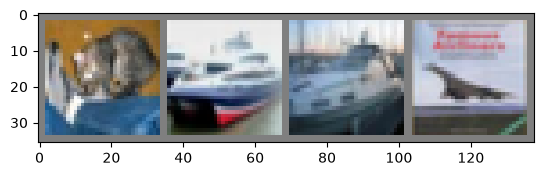

GroundTruth:    cat  ship  ship plane


In [27]:
dataiter = iter(vistestloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join('%5s' % classes[labels[j]] for j in range(4)))

### 3.8 Load a model

Recreate the architecture with `build_model()`, then load the saved `state_dict`. The grading script follows the same pattern with the `build_model()` in your submitted `model.py` and your submitted `model.pt`.


In [10]:
net = build_model()


def load_model(net, path):
    state = torch.load(path, map_location='cpu', weights_only=True)
    net.load_state_dict(state, strict=True)
    net.eval()
    return net


load_model(net, PATH)


NameError: name 'PATH' is not defined

Okay, now let us see what the neural network thinks these examples above are:



In [29]:
net = net.to(device)
with torch.inference_mode():
    outputs = net(images.to(device))


The outputs are energies for the 10 classes.
The higher the energy for a class, the more the network
thinks that the image is of the particular class.
So, let's get the index of the highest energy:



In [30]:
predicted = outputs.argmax(dim=1).cpu().tolist()
print('Predicted: ', ' '.join('%5s' % classes[predicted[j]] for j in range(4)))


Predicted:    cat truck  ship plane


### 3.9 Define testing code


In [31]:
def test(net, loader):
    net.to(device)
    _, accuracy_percent = evaluate(net, loader)
    print(f'Accuracy on {len(loader.dataset)} public test images: {accuracy_percent:.2f}%')
    return accuracy_percent


In [32]:
test(net, testloader)

Accuracy on 10000 public test images: 51.69%


51.69

### 3.10 See accuracy of each class

The public test set can also show which classes are difficult.


In [33]:
def class_test(net, loader):
    correct_pred = {classname: 0 for classname in classes}
    total_pred = {classname: 0 for classname in classes}
    net.to(device)
    net.eval()
    with torch.inference_mode():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            predictions = net(images).argmax(dim=1)
            for label, prediction in zip(labels.cpu().tolist(),
                                         predictions.cpu().tolist()):
                classname = classes[label]
                correct_pred[classname] += int(label == prediction)
                total_pred[classname] += 1

    for classname in classes:
        count = total_pred[classname]
        if count:
            acc = 100.0 * correct_pred[classname] / count
            print(f'Accuracy for class {classname:5s}: {acc:.1f}%')


In [34]:
class_test(net, testloader)

Accuracy for class plane: 52.8%
Accuracy for class car  : 57.0%
Accuracy for class bird : 39.9%
Accuracy for class cat  : 39.4%
Accuracy for class deer : 47.2%
Accuracy for class dog  : 38.0%
Accuracy for class frog : 49.3%
Accuracy for class horse: 56.9%
Accuracy for class ship : 66.2%
Accuracy for class truck: 70.2%


## Part 4 — Model Development Exercises


### Exercise 1 — Build a Convolutional Neural Network

Although programming frameworks make convolutions easy to use, they remain one of the hardest concepts to understand in Deep Learning. A convolution layer transforms an input volume into an output volume of different size, as shown below.

![conv_nn.png](conv_nn.png)

Implement the following architecture. After you finish the class, use the next check cell to construct it through `build_model()` and verify the output shape before training.

    conv2d, 5x5, 3->8, padding=2
    ReLU
    conv2d, 5x5, 8->16, padding=2, stride=2
    ReLU
    conv2d, 5x5, 16->32, padding=2
    ReLU
    conv2d, 5x5, 32->64, padding=2, stride=2
    ReLU
    conv2d, 5x5, 64->128, padding=2
    maxpool2d, 2x2
    ReLU
    flatten (128*4*4 features)
    fc, 2048->120
    ReLU
    fc, 120->84
    ReLU
    fc, 84->10


In [4]:
class ConvolutionNet(nn.Module):
    def __init__(self):
        super().__init__()
        '''
        Implement here
        '''
        pass

    def forward(self, x):
        '''
        Implement here
        '''
        pass
        return x


#### Inspect the CNN architecture

Run this block after implementing `ConvolutionNet`. `print(cnn_net)` prints your model structure, and the remaining code checks a two-image input. The next training block uses the same `cnn_net`, created through `build_model()`.


In [ ]:
def build_model():
    return ConvolutionNet()


cnn_net = build_model()
cnn_net.eval()
print(cnn_net)
with torch.inference_mode():
    cnn_output = cnn_net(torch.zeros(2, 3, 32, 32))
print('Output shape:', tuple(cnn_output.shape))
assert cnn_output.shape == (2, 10)


**One possible reference output:**

```text
ConvolutionNet(
  (conv1): Conv2d(3, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv3): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv4): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv5): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
Output shape: (2, 10)
```

This is a reference output, so minor formatting differences are acceptable. `F.relu` is applied in `forward` and therefore is not listed among the registered layers. If you use different layer names or organize the layers differently, the printed model structure will change too.


#### Train the convolutional neural network

Train this CNN with learning rate 1e-2 for 6 epochs.

You should see the training loss is around 0.9 and accuracy is around 67%.


In [7]:
# Create cnn_optimizer for cnn_net, then create cnn_history using train(..., cnn_optimizer, 6).
# Implement here.


#### Visualize CNN training

Plot both training and validation curves after filling the training cell above.


In [ ]:
visualize_history(cnn_history, 'CNN')


#### Test the convolutional neural network

Evaluate the selected CNN on the public CIFAR-10 test set using the provided `test` function.


In [ ]:
'''
Implement here, use the test function provided.
'''

#### Accuracy (each class) of CNN

Test this CNN on the test dataset to see the accuracy of each class.

In [ ]:
'''
Implement here, use the class_test function provided.
'''

### Exercise 2 — Add Batch Normalization

Add `BatchNorm2d` after each convolution and before the activation. After you finish the class, use the next check cell to construct it through `build_model()` and verify the output shape before training.


In [5]:
class ConvolutionBNNet(nn.Module):
    def __init__(self):
        super().__init__()
        '''
        Implement here.
        '''
        pass

    def forward(self, x):
        '''
        Implement here
        '''
        pass
        return x


#### Inspect the CNN with BN architecture

Run this block after implementing `ConvolutionBNNet`. `print(cnn_bn_net)` prints your model structure, and the remaining code checks a two-image input. The next training block uses the same `cnn_bn_net`, created through `build_model()`.


In [ ]:
def build_model():
    return ConvolutionBNNet()


cnn_bn_net = build_model()
cnn_bn_net.eval()
print(cnn_bn_net)
with torch.inference_mode():
    cnn_bn_output = cnn_bn_net(torch.zeros(2, 3, 32, 32))
print('Output shape:', tuple(cnn_bn_output.shape))
assert cnn_bn_output.shape == (2, 10)


**One possible reference output:**

```text
ConvolutionBNNet(
  (conv1): Conv2d(3, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
Output shape: (2, 10)
```

This is a reference output, so minor formatting differences are acceptable. `F.relu` is applied in `forward` and therefore is not listed among the registered layers. If you use different layer names or organize the layers differently, the printed model structure will change too.


#### Train the CNN with BN

Use `cnn_bn_net`, created by `build_model()` in the check block above. Train with learning rate `1e-2` for 5 epochs, passing both `trainloader` and `valloader` to `train`. Plot both loss and accuracy curves and retain the best-validation checkpoint.


In [ ]:
# Create cnn_bn_optimizer for cnn_bn_net, then create cnn_bn_history using train(..., cnn_bn_optimizer, 5).
# Implement here.


#### Visualize CNN with BN training

Plot both training and validation curves after filling the training cell above.


In [ ]:
visualize_history(cnn_bn_history, 'CNN with BN')


#### Test the CNN with BN

Evaluate the selected CNN with BN on the public CIFAR-10 test set using the provided `test` function.


In [ ]:
'''
Implement here
'''

#### Accuracy (each class) of CNN with BN

Use `class_test` to inspect the public-test accuracy of each class.


In [ ]:
'''
Implement here, use the class_test function provided.
'''

### Exercise 3 — Design Your Own Model

Design your own architecture or optimization method and explain at least one improvement strategy. Use the same `train` and validation workflow. Redefine `build_model()` so it creates the final architecture, and train the model returned by that function. Save the best-validation weights as `model.pt`; these must match the no-argument `build_model()` in the submitted `model.py`.

For final grading, the TA uses the same evaluation transform defined in [Section 2.1](#2.1-Define-the-dataset-and-dataloader):

```python
transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5)),
])
```

Therefore, your model receives a `torch.float32` RGB tensor of shape `[N, 3, 32, 32]` with values in `[-1, 1]`, and must output a tensor of shape `[N, 10]` containing unnormalized logits in CIFAR-10 class order. Do not normalize the input again inside `forward`. Do not download weights or start training when `model.py` is imported. The same `model.pt` checkpoint will be evaluated on both the public test set and the unseen evaluation data.


In [ ]:
'''
Implement here
'''

#### Final Evaluation Check

Your `model.py` must expose a no-argument `build_model()` and contain all architecture code it needs. It must not start training or load test data on import.

A minimal `model.py` contains your final model class and a factory like this:

```python
def build_model():
    return FinalNet()  # FinalNet is defined in model.py
```

Save the best-validation weights of your final model with `torch.save(model.state_dict(), 'model.pt')` (replace `model` with your trained final model variable name). Run the block below after creating both files. It loads them through the grading interface and reports accuracy on the **public CIFAR-10 test set**. The unseen evaluation data is tested separately by the TAs.

The block below is self-contained: after creating `model.py` and `model.pt`, you can restart the kernel and run only this block. It intentionally repeats the required imports, device selection, evaluation transform, data loader, checkpoint loading, and accuracy calculation. Set `DATA_ROOT` in the block to the directory where CIFAR-10 is, or should be, stored. If the dataset is not already present there, torchvision downloads it automatically.


In [ ]:
# This cell is self-contained. It does not depend on earlier notebook cells.
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path

import torch
import torchvision
import torchvision.transforms as transforms

# Change only this path if CIFAR-10 is stored elsewhere.
DATA_ROOT = Path('./data')

submission_dir = Path.cwd()
model_path = submission_dir / 'model.py'
checkpoint_path = submission_dir / 'model.pt'
assert model_path.is_file(), f'{model_path} is missing'
assert checkpoint_path.is_file(), f'{checkpoint_path} is missing'

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Import model.py and construct the submitted architecture.
spec = spec_from_file_location('submission_model', model_path)
assert spec is not None and spec.loader is not None, 'Could not import model.py'
submission_module = module_from_spec(spec)
spec.loader.exec_module(submission_module)
assert hasattr(submission_module, 'build_model'), 'model.py must define build_model()'
submission_model = submission_module.build_model()
assert isinstance(submission_model, torch.nn.Module), 'build_model() must return nn.Module'

# Load model.pt into exactly that architecture.
state = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
submission_model.load_state_dict(state, strict=True)
submission_model = submission_model.to(device).eval()

# Check the required input/output interface before evaluating accuracy.
with torch.inference_mode():
    submission_output = submission_model(
        torch.zeros(2, 3, 32, 32, dtype=torch.float32, device=device)
    )
assert isinstance(submission_output, torch.Tensor), 'The model output must be a tensor'
assert submission_output.shape == (2, 10), 'Expected output shape (2, 10)'
assert torch.isfinite(submission_output).all(), 'The model output contains NaN or Inf'
print('Submission model loaded successfully; output shape:',
      tuple(submission_output.shape))

# Use exactly the same preprocessing as final grading.
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5)),
])
public_testset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=eval_transform,
)
public_testloader = torch.utils.data.DataLoader(
    public_testset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
)

correct = 0
total = 0
with torch.inference_mode():
    for images, labels in public_testloader:
        images = images.to(device)
        labels = labels.to(device)
        logits = submission_model(images)
        assert logits.shape == (images.size(0), 10), \
            f'Expected output shape ({images.size(0)}, 10), got {tuple(logits.shape)}'
        assert torch.isfinite(logits).all(), 'The model output contains NaN or Inf'
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

public_test_accuracy = 100.0 * correct / total
print(f'Accuracy on {total} public test images: {public_test_accuracy:.2f}%')


**Congratulations!**

Submit `Assignment_1.ipynb`, `model.py`, `model.pt`, and `report.pdf`.
